In [1]:
import zipfile

zip_path = "./Teeth DataSet.zip"

zip_ref = zipfile.ZipFile(zip_path , 'r')
zip_ref.extractall("./")
zip_ref.close()


In [ ]:
# define the folders using os

import os

train_dir = os.path.join('.','Teeth_Dataset','Training')
validation_dir = os.path.join('.','Teeth_Dataset','Validation')
test_dir = os.path.join('.','Teeth_Dataset','Testing')


In [ ]:
# define the seven class 

class_names = ['CaS','CoS','Gum','MC','OC','OLP','OT']

train_class_dirs = {
    class_name : os.path.join(train_dir,class_name)
    for class_name in class_names
}

validation_class_dirs = {
    class_name : os.path.join(validation_dir,class_name)
    for class_name in class_names
}

test_class_dir = {
    class_name : os.path.join(test_dir,class_name)
    for class_name in class_names
}

In [4]:
# check the number of images 

for class_name in class_names:
    print(
        class_name,
        'Training:' , len(os.listdir(train_class_dirs[class_name])),
        'Validation:' , len(os.listdir(validation_class_dirs[class_name])),
        'Testing:' , len(os.listdir(test_class_dir[class_name]))
    )

CaS Training: 480 Validation: 160 Testing: 160
CoS Training: 450 Validation: 149 Testing: 149
Gum Training: 360 Validation: 120 Testing: 120
MC Training: 540 Validation: 180 Testing: 180
OC Training: 324 Validation: 108 Testing: 108
OLP Training: 540 Validation: 180 Testing: 180
OT Training: 393 Validation: 131 Testing: 131


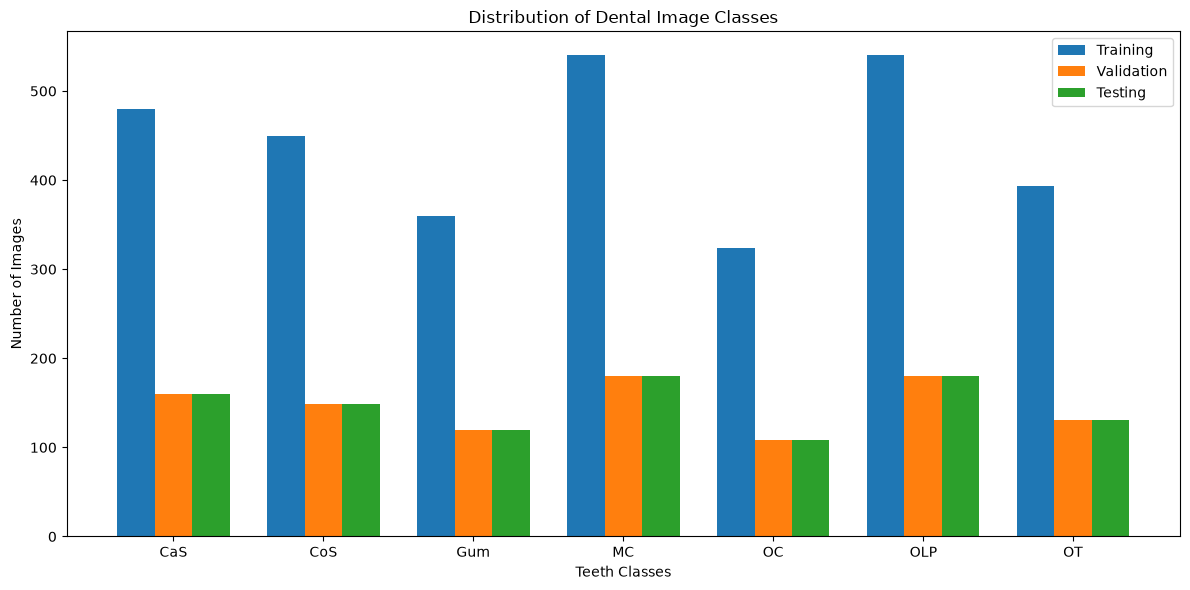

In [5]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ["CaS", "CoS", "Gum", "MC", "OC", "OLP", "OT"]

training_counts = [480, 450, 360, 540, 324, 540, 393]
validation_counts = [160, 149, 120, 180, 108, 180, 131]
testing_counts = [160, 149, 120, 180, 108, 180, 131]

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, training_counts, width, label="Training")
plt.bar(x, validation_counts, width, label="Validation")
plt.bar(x + width, testing_counts, width, label="Testing")

plt.xlabel("Teeth Classes")
plt.ylabel("Number of Images")
plt.title("Distribution of Dental Image Classes")
plt.xticks(x, class_names)
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
import tensorflow as tf

ImageDataGenerator = tf.keras.preprocessing.image.ImageDataGenerator

#apply normalization and augmentation

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

I0000 00:00:1785827057.770046    6320 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785827057.819509    6320 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785827058.810361    6320 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


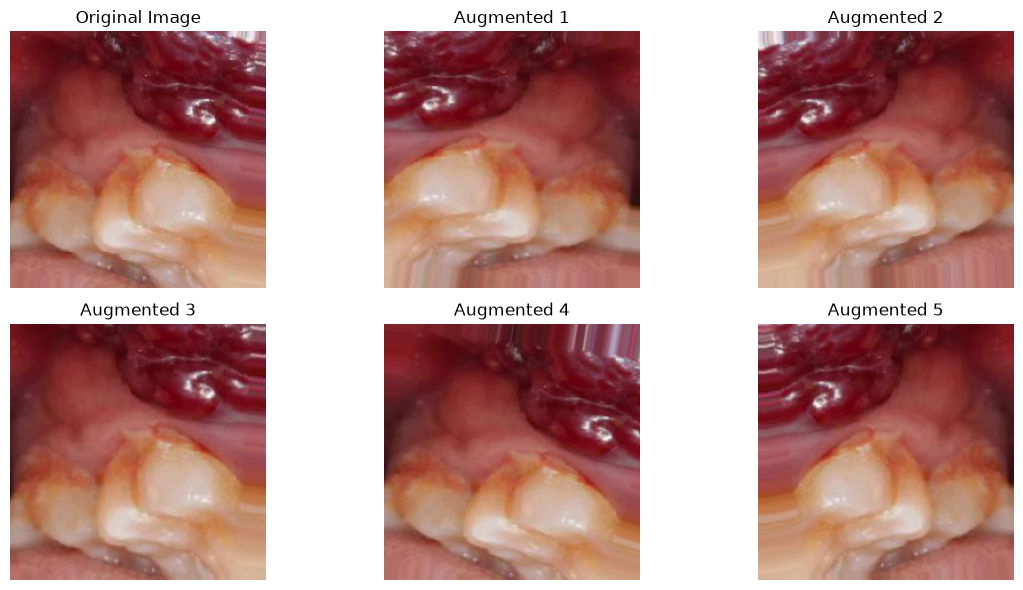

In [8]:
from tensorflow.keras.preprocessing import image 

img_path = "/mnt/c/Users/MSI/Desktop/task3/Teeth_Dataset/Training/MC/mc_1200_0_2140.jpg"

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)


datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

augmented_images = []

for i in range(5):
    for batch in datagen.flow(
        img_array,
        batch_size=1
    ):
        augmented_images.append(batch[0])
        break


plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(img_array[0].astype("uint8"))
plt.title("Original Image")
plt.axis("off")


for i in range(5):
    plt.subplot(2,3,i+2)
    plt.imshow(
        augmented_images[i].astype("uint8")
    )
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# apply normalization on testing and validation

validation_datagen = ImageDataGenerator(
    rescale = 1.0/255.0
)

teat_datagen = ImageDataGenerator(
    rescale = 1.0/255.0
)

In [10]:
# download images after processing
img_size = (224,224)
batch_size = 32

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size = img_size,
    batch_size = batch_size, 
    class_mode = 'categorical',
    shuffle = True,
    seed = 42
)

validation_gen = validation_datagen.flow_from_directory(
    validation_dir,
    target_size = img_size,
    batch_size = batch_size, 
    class_mode = 'categorical',
    shuffle = False,
)

test_gen = teat_datagen.flow_from_directory(
    test_dir,
    target_size = img_size,
    batch_size = batch_size, 
    class_mode = 'categorical',
    shuffle = False,
)

Found 3087 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.


In [11]:
# model building

tf.keras.backend.clear_session()

model = tf.keras.Sequential([
    # input layer
    tf.keras.layers.Input(shape=(224,224,3)),

    # hidden layer
    tf.keras.layers.Conv2D(
        32,
        kernel_size = (3,3),
        activation = 'relu',
        padding = 'same'
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(
        32,
        kernel_size = (3,3),
        activation = 'relu',
        padding = 'same'
    ),

    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    tf.keras.layers.Conv2D(
        64,
        kernel_size=(3,3),
        activation='relu',
        padding = 'same'
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    
    tf.keras.layers.Conv2D(
            64,
            kernel_size=(3,3),
            activation='relu',
            padding = 'same'
        ),

    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),


    tf.keras.layers.Conv2D(
            128,
            kernel_size=(3,3),
            activation='relu',
            padding = 'same'
        ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(
            128,
            kernel_size=(3,3),
            activation='relu',
            padding = 'same'
        ),

    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),



    tf.keras.layers.Conv2D(
                256,
                kernel_size=(3,3),
                activation='relu',
                padding = 'same'
            ),
    
    tf.keras.layers.BatchNormalization(),


    tf.keras.layers.Conv2D(
                256,
                kernel_size=(3,3),
                activation='relu',
                padding = 'same'
            ),
    
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),



    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        256,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.30),

    # output layer
    tf.keras.layers.Dense(
        7,
        activation='softmax'
    )
])

I0000 00:00:1785827131.959429    6320 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [12]:
# model structure display

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,241,767 (4.74 MB)

 Trainable params: 1,240,807 (4.73 MB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
# preparing the model for training 

model.compile(
    optimizer = tf.keras.optimizers.Adam(
        learning_rate = 0.0003
    ),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [14]:
Early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

Reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.000001
)

Model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_teeth_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [15]:
with tf.device("/GPU:0"):
    a = tf.random.normal((2000, 2000))
    result = tf.matmul(a, a)

print("Device used:", result.device)

Device used: /job:localhost/replica:0/task:0/device:GPU:0


In [16]:
history = model.fit(
    train_gen,
    validation_data=validation_gen,
    epochs=35,
    callbacks=[
        Early_stopping,
        Reduce_learning_rate,
        Model_checkpoint
    ]
)

Epoch 1/35


I0000 00:00:1785827185.398517    6320 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1785827190.364610    7888 service.cc:153] XLA service 0x7721e0045030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785827190.364644    7888 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.0)
I0000 00:00:1785827190.453696    7888 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785827191.204710    7888 cuda_dnn.cc:461] Loaded cuDNN version 92500
I0000 00:00:1785827191.334052    7888 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5437__.89
I0000 00:00:1785827216.140000    7888 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proce

84/97 ━━━━━━━━━━━━━━━━━━━━ 12s 950ms/step - accuracy: 0.3527 - loss: 1.6577

I0000 00:00:1785827296.250482    7890 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5437__.89


97/97 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.3628 - loss: 1.6365 - val_accuracy: 0.1449 - val_loss: 2.4863 - learning_rate: 3.0000e-04
Epoch 2/35
97/97 ━━━━━━━━━━━━━━━━━━━━ 55s 564ms/step - accuracy: 0.4914 - loss: 1.3555 - val_accuracy: 0.1449 - val_loss: 3.1520 - learning_rate: 3.0000e-04
Epoch 3/35
97/97 ━━━━━━━━━━━━━━━━━━━━ 54s 558ms/step - accuracy: 0.5815 - loss: 1.1386 - val_accuracy: 0.2130 - val_loss: 4.6193 - learning_rate: 3.0000e-04
Epoch 4/35
97/97 ━━━━━━━━━━━━━━━━━━━━ 70s 723ms/step - accuracy: 0.6754 - loss: 0.9032 - val_accuracy: 0.2831 - val_loss: 5.2588 - learning_rate: 1.5000e-04
Epoch 5/35
97/97 ━━━━━━━━━━━━━━━━━━━━ 80s 826ms/step - accuracy: 0.7353 - loss: 0.7441 - val_accuracy: 0.2607 - val_loss: 3.6769 - learning_rate: 1.5000e-04
Epoch 6/35
97/97 ━━━━━━━━━━━━━━━━━━━━ 63s 643ms/step - accuracy: 0.7891 - loss: 0.6102 - val_accuracy: 0.3988 - val_loss: 1.9456 - learning_rate: 7.5000e-05
Epoch 7/35
97/97 ━━━━━━━━━━━━━━━━━━━━ 54s 555ms/step - accuracy: 0.8173

In [17]:
test_loss , test_accuracy = model.evaluate(test_gen)

print('test Loss:',test_loss)
print('Test Accuracy:',test_accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 930ms/step - accuracy: 0.9689 - loss: 0.0986
test Loss: 0.09857465326786041
Test Accuracy: 0.9688715934753418


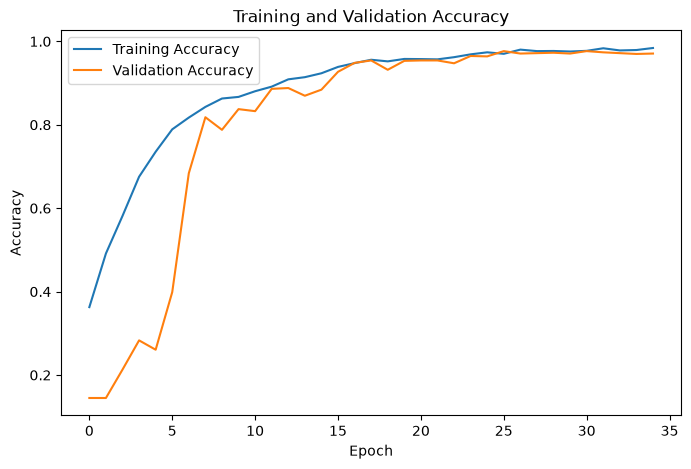

In [18]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'],label = 'Validation Accuracy')
plt.xlabel( 'Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

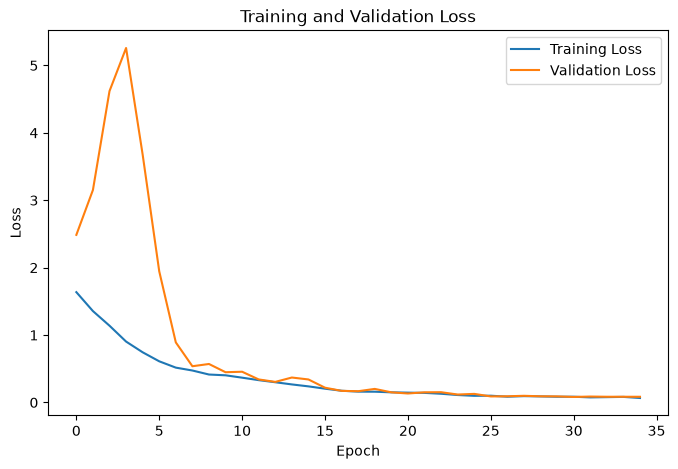

In [19]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel( 'Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [20]:
model.save("teeth_classification_model.keras")

In [21]:

best_model = tf.keras.models.load_model(
    "teeth_classification_model.keras"
)

test_gen.reset()

prediction_probabilities = best_model.predict(
    test_gen,
    verbose=1
)

predicted_classes = np.argmax(
    prediction_probabilities,
    axis=1
)

true_classes = test_gen.classes

class_names = list(
    test_gen.class_indices.keys()
)

print("Class names:", class_names)
print("True labels:", len(true_classes))
print("Predicted labels:", len(predicted_classes))

33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step
Class names: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
True labels: 1028
Predicted labels: 1028


In [22]:
from sklearn.metrics import classification_report

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

         CaS     0.9636    0.9938    0.9785       160
         CoS     0.9801    0.9933    0.9867       149
         Gum     0.9914    0.9583    0.9746       120
          MC     0.9441    0.9389    0.9415       180
          OC     0.9455    0.9630    0.9541       108
         OLP     0.9770    0.9444    0.9605       180
          OT     0.9850    1.0000    0.9924       131

    accuracy                         0.9689      1028
   macro avg     0.9695    0.9702    0.9697      1028
weighted avg     0.9690    0.9689    0.9688      1028



In [23]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score
)

accuracy = accuracy_score(
    true_classes,
    predicted_classes
)

precision = precision_score(
    true_classes,
    predicted_classes,
    zero_division=0,
    average= 'macro'
)

recall = recall_score(
    true_classes,
    predicted_classes,
    zero_division=0,
    average= 'macro'
)

F1_score = f1_score(
    true_classes,
    predicted_classes,
    average= 'macro',
    zero_division= 0
)

print(f" Accuracy: {accuracy:.4f}")
print(f" Precision: {precision:.4f}")
print(f" Recall: {recall:.4f}")
print(f" F1-Score: {F1_score:.4f}")

 Accuracy: 0.9689
 Precision: 0.9695
 Recall: 0.9702
 F1-Score: 0.9697
